# 1. Import the library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from scipy.stats.mstats import winsorize
from sklearn.model_selection import KFold, StratifiedKFold

In [2]:
# 1.1 setup visualization
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("All the settings are predefined ! ")

All the settings are predefined ! 


In [3]:
# 1.2 Load Data
base_dir = Path.cwd().parent
data_path_train = base_dir / "data" / "raw" / "olist_brazil_ml.csv"
train_data = pd.read_csv(data_path_train)
print(f"Training set: {train_data.shape[0]: ,} rows x {train_data.shape[1]} columns")

Training set:  95,343 rows x 27 columns


In [4]:
train_df = train_data.copy()
train_df.head()

,review_score,is_satisfied,delivery_delay_days,estimated_delivery_days,actual_delivery_days,carrier_to_customer_days,review_answer_delay_days,total_order_value,total_freight_value,total_items,...,customer_lng,seller_state,seller_lat,seller_lng,seller_total_orders,seller_late_rate,seller_avg_review_score,seller_avg_delay,month,day_name
0,4,0,-15,22,7.0,5.0,1,34.59,12.69,1,...,-47.9248,SP,-21.1901,-47.7879,23,0.0000,4.174,-13.52,5,Monday
1,5,0,-8,21,13.0,6.0,3,126.54,26.74,2,...,-46.9014,SP,-20.8067,-49.3892,1391,0.0757,3.994,-10.94,2,Tuesday
2,5,0,-6,14,8.0,7.0,0,127.55,27.65,1,...,-45.9487,PR,-24.9447,-53.4903,94,0.0099,4.317,-17.20,8,Tuesday
3,5,0,-13,20,7.0,4.0,0,112.71,13.71,1,...,-46.8968,SP,-21.1127,-47.7908,376,0.0845,4.169,-11.65,8,Saturday
4,5,0,-7,9,2.0,1.0,0,35.84,7.94,1,...,-46.5552,SP,-23.1147,-46.5529,396,0.0794,4.072,-9.65,6,Monday


# 2.Data Inspection & Preprocessing

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95343 entries, 0 to 95342
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   review_score              95343 non-null  int64  
 1   is_satisfied              95343 non-null  int64  
 2   delivery_delay_days       95343 non-null  int64  
 3   estimated_delivery_days   95343 non-null  int64  
 4   actual_delivery_days      95335 non-null  float64
 5   carrier_to_customer_days  95334 non-null  float64
 6   review_answer_delay_days  95343 non-null  int64  
 7   total_order_value         95340 non-null  float64
 8   total_freight_value       95343 non-null  float64
 9   total_items               95343 non-null  int64  
 10  freight_ratio             95340 non-null  float64
 11  payment_installments      95340 non-null  float64
 12  payment_value             95340 non-null  float64
 13  payment_type              95343 non-null  str    
 14  category_name_eng

In [6]:
train_df = train_df.drop(columns=['review_score'])
print(f'Columns sau drop: {train_df.shape[1]}')
print(train_df.columns.tolist())

Columns sau drop: 26
['is_satisfied', 'delivery_delay_days', 'estimated_delivery_days', 'actual_delivery_days', 'carrier_to_customer_days', 'review_answer_delay_days', 'total_order_value', 'total_freight_value', 'total_items', 'freight_ratio', 'payment_installments', 'payment_value', 'payment_type', 'category_name_english', 'customer_state', 'customer_lat', 'customer_lng', 'seller_state', 'seller_lat', 'seller_lng', 'seller_total_orders', 'seller_late_rate', 'seller_avg_review_score', 'seller_avg_delay', 'month', 'day_name']


## 2.1 Missing value

In [7]:
def missing_report(df):
    miss = df.isnull().sum()
    miss = miss[miss > 0].rename("count")
    pct  = (miss / len(df) * 100).rename("%")
    return pd.concat([miss, pct], axis=1).sort_values("%", ascending=False)

print("Missing values before treatment:")
display(missing_report(train_df))

Missing values before treatment:


,count,%
customer_lat,262,0.274797
customer_lng,262,0.274797
seller_lng,212,0.222355
seller_lat,212,0.222355
carrier_to_customer_days,9,0.009440
actual_delivery_days,8,0.008391
payment_value,3,0.003147
payment_installments,3,0.003147
freight_ratio,3,0.003147
total_order_value,3,0.003147


In [8]:
before = len(train_df)

# Drop rows with missing geolocation - important for distance-based features
train_df = train_df.dropna(subset=['customer_lat', 'customer_lng', 'seller_lat', 'seller_lng'])

# Drop raw missing payment info - important for model learning
train_df = train_df.dropna(subset=['freight_ratio', 'payment_installments', 'payment_value'])

# Fill missing values with median
for col in ['actual_delivery_days', 'carrier_to_customer_days', 'total_order_value']:
    if train_df[col].isnull().sum() > 0:
        train_df[col] = train_df[col].fillna(train_df[col].median())

In [9]:
print(f"Dropped before: {before} - after :{len(train_df)}")
total_miss = train_df.isnull().sum()
total_miss[total_miss > 0]

Dropped before: 95343 - after :94867


Series([], dtype: int64)

## 2.2 Outlier Treatment

In [10]:
# Set up histogram and boxplot
def plot_hist_box(df, col):
    data = df[col]

    # Iqr, lower, upper
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    fig, axes  = plt.subplots(1, 2, figsize = (14,5))
    # Histogram
    sns.histplot(data, kde = True, ax = axes[0])
    axes[0].axvline(lower, color = 'red', linestyle="--", label="Lower bound")
    axes[0].axvline(upper, color = 'blue', linestyle="--", label="Upper bound")
    axes[0].set_title(f'Histogram — {col}  (skew={data.skew():.2f})')
    axes[0].legend()

    # Boxplot
    sns.boxplot(x = data, ax = axes[1])
    axes[1].axvline(lower, color='red',  linestyle='--')
    axes[1].axvline(upper, color='blue', linestyle='--')
    axes[1].set_title(f'Boxplot — {col}')
    plt.tight_layout()
    plt.show()

def clip_and_log(df, col, lo_pct = 0.01, hi_pct = 0.99):
    lower = df[col].quantile(lo_pct)
    upper = df[col].quantile(hi_pct)

    df[col] = df[col].clip(lower , upper)
    df[f"{col}_log"] = np.log1p(df[col])
    return df

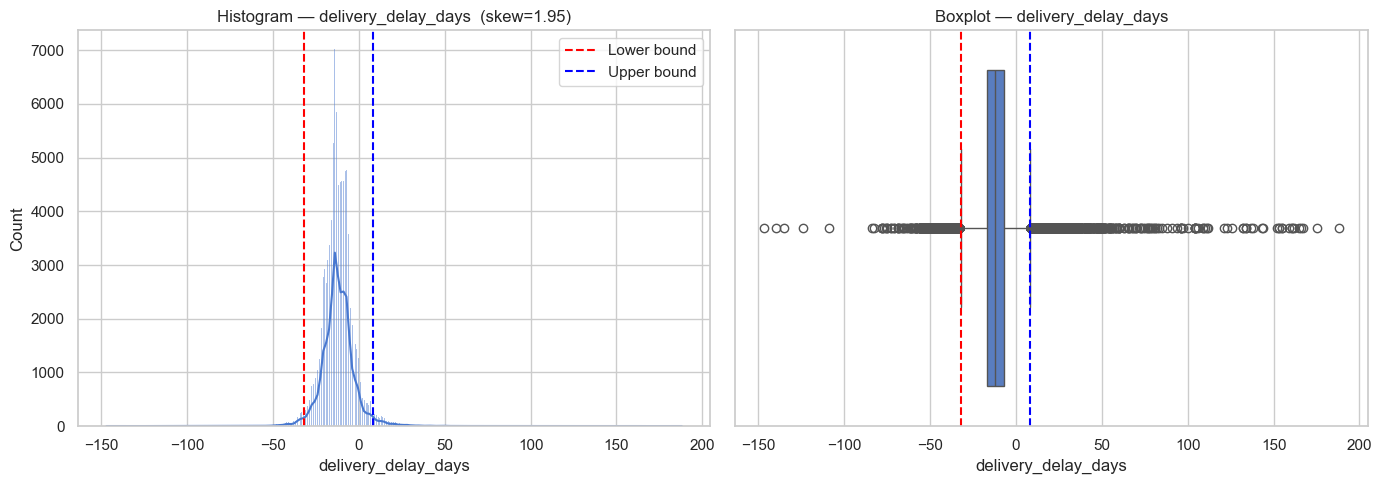

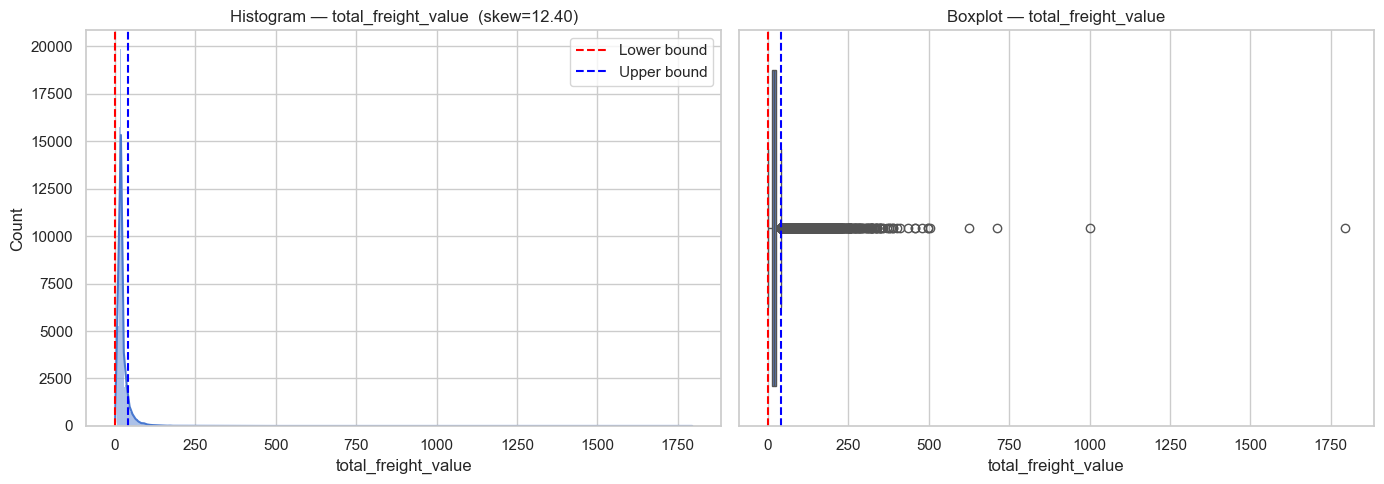

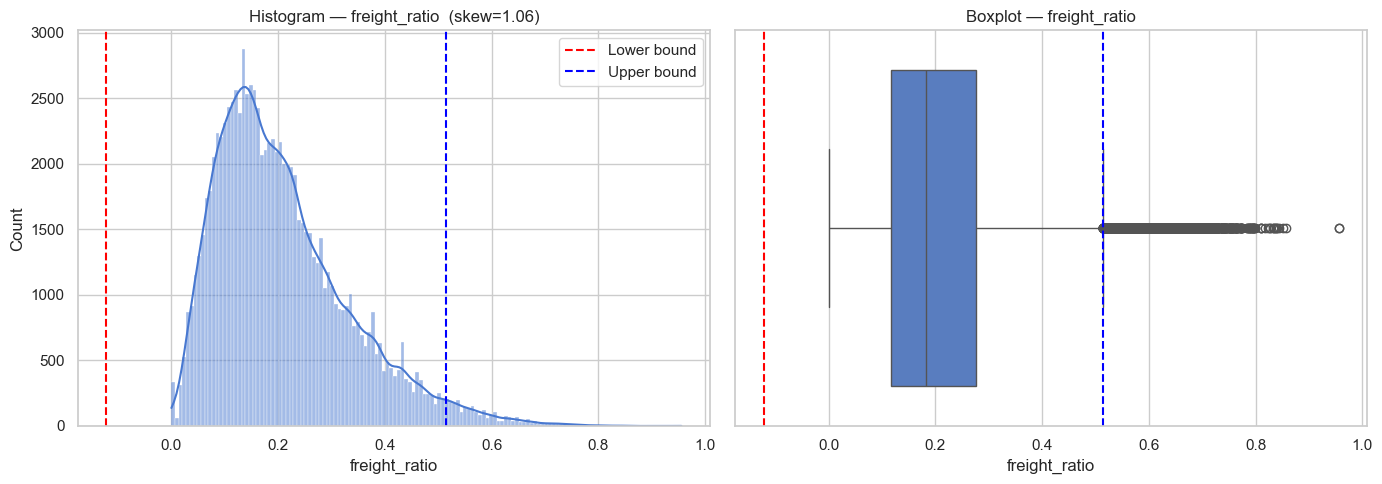

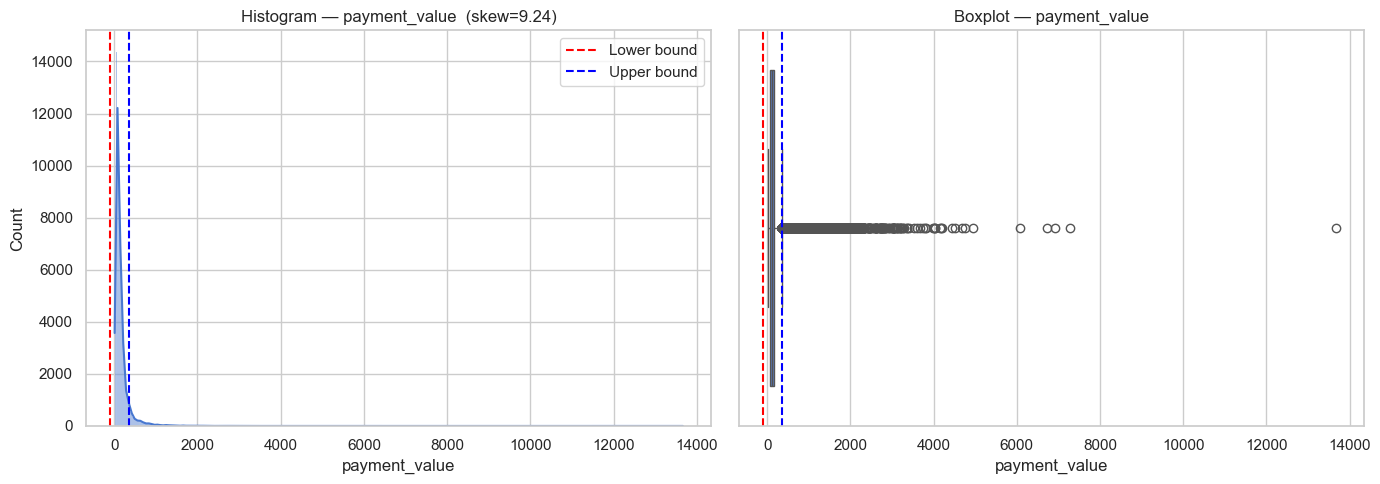

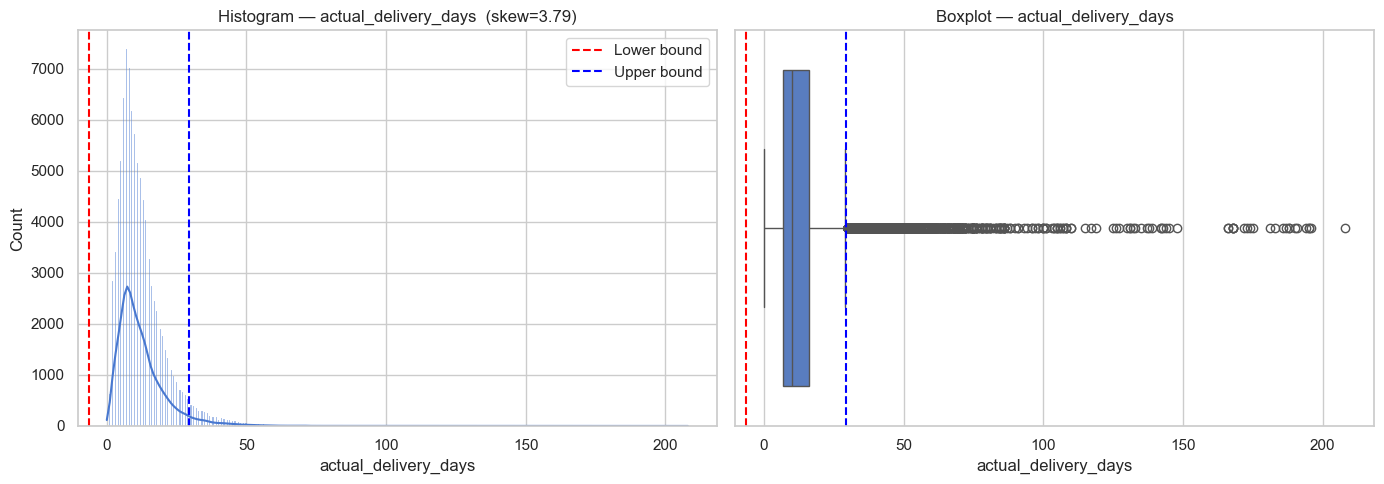

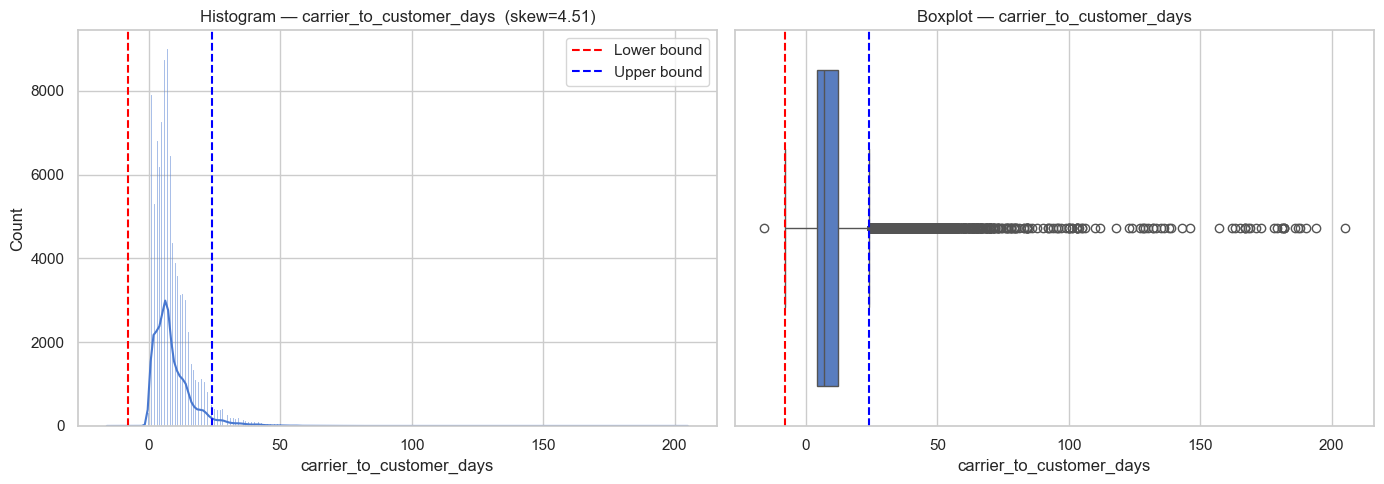

In [11]:
# Check outliers in key numeric features
outlier_cols = ['delivery_delay_days', 'total_freight_value', 'freight_ratio', 
                'payment_value', 'actual_delivery_days','carrier_to_customer_days' 
            ]
for col in outlier_cols:
    plot_hist_box(train_df, col)

In [12]:
# delivery_delay_days: only clip (not log because of negative values = early delivery)
lo = train_df['delivery_delay_days'].quantile(0.01)
hi = train_df['delivery_delay_days'].quantile(0.99)
train_df['delivery_delay_days'] = train_df['delivery_delay_days'].clip(lo, hi)

# carrier_to_customer_days is positive but has some negative values (early delivery), so only clip, no log
lo = train_df['carrier_to_customer_days'].quantile(0.01)
hi = train_df['carrier_to_customer_days'].quantile(0.99)
train_df['carrier_to_customer_days'] = train_df['carrier_to_customer_days'].clip(lo, hi)

clip_log_cols = ['total_freight_value', 'freight_ratio', 'payment_value']
for col in clip_log_cols:
    train_df = clip_and_log(train_df, col)

train_df = train_df.drop(columns=clip_log_cols)

for col in ['actual_delivery_days']:
    lo = train_df[col].quantile(0.01)
    hi = train_df[col].quantile(0.99)
    train_df[col] = train_df[col].clip(lo, hi)      
    train_df[f'{col}_log'] = np.log1p(train_df[col])

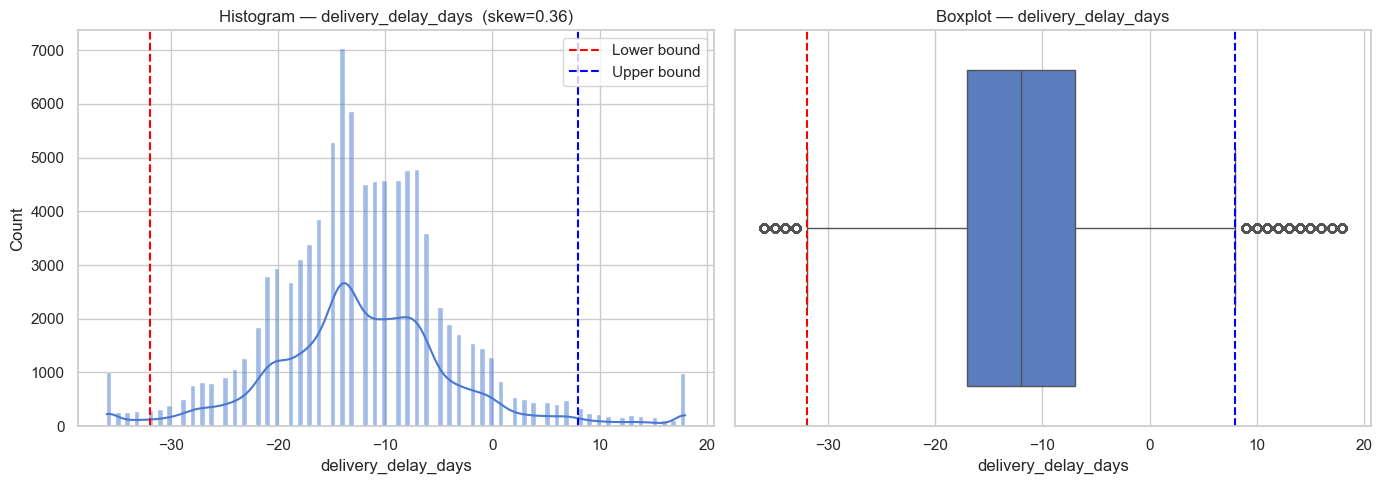

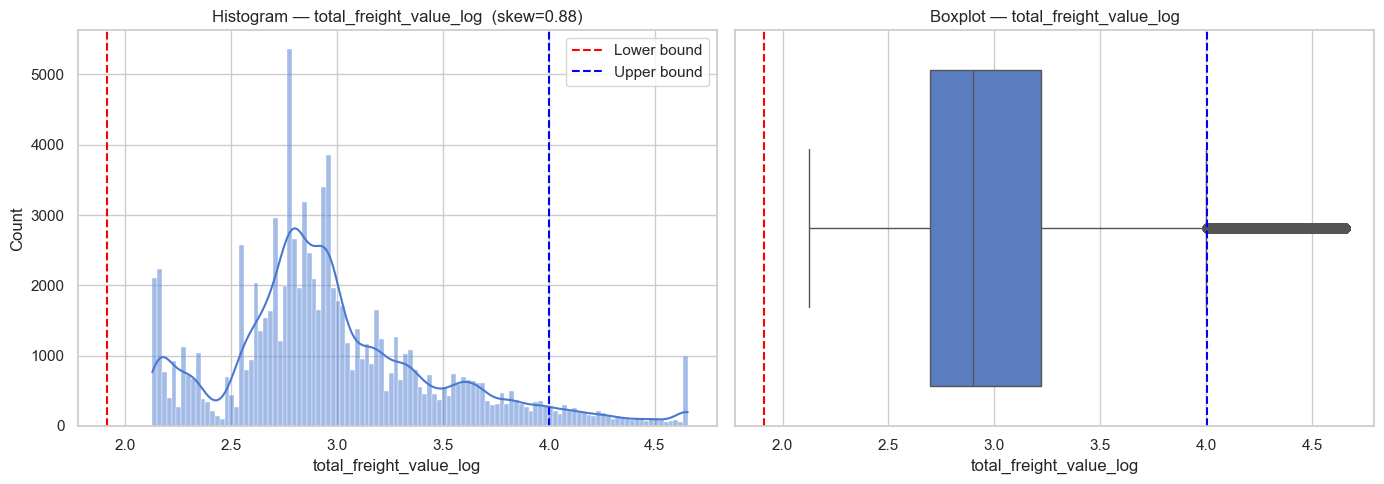

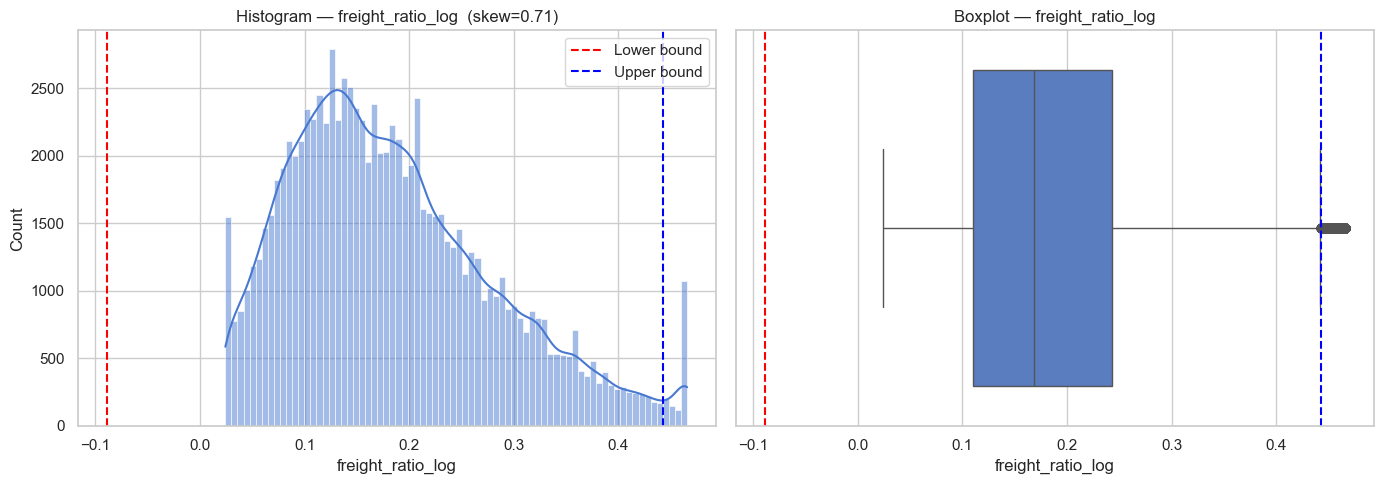

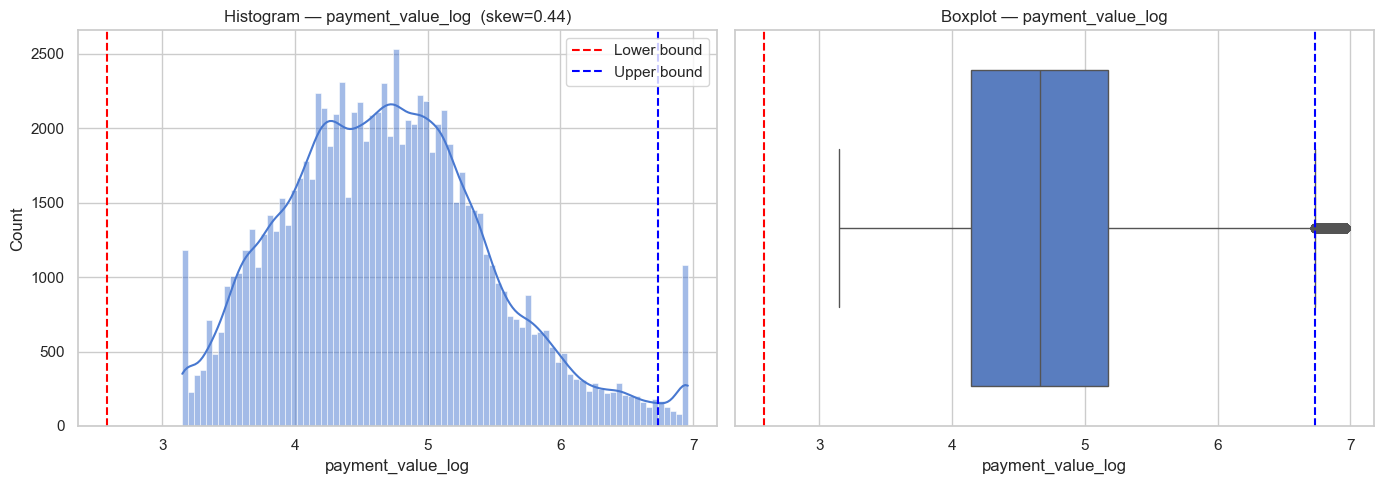

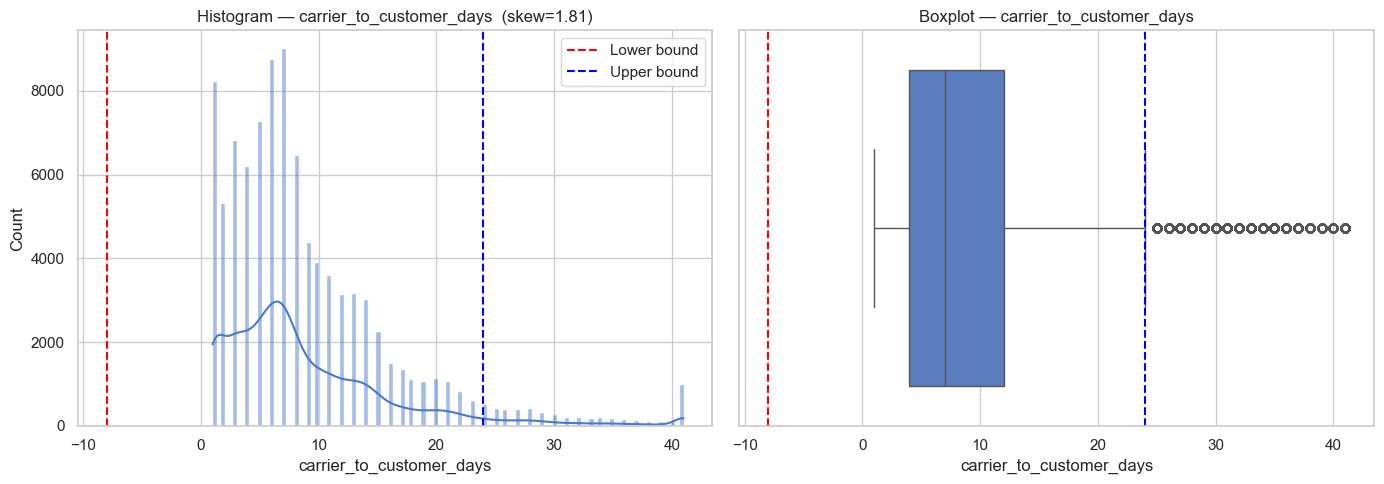

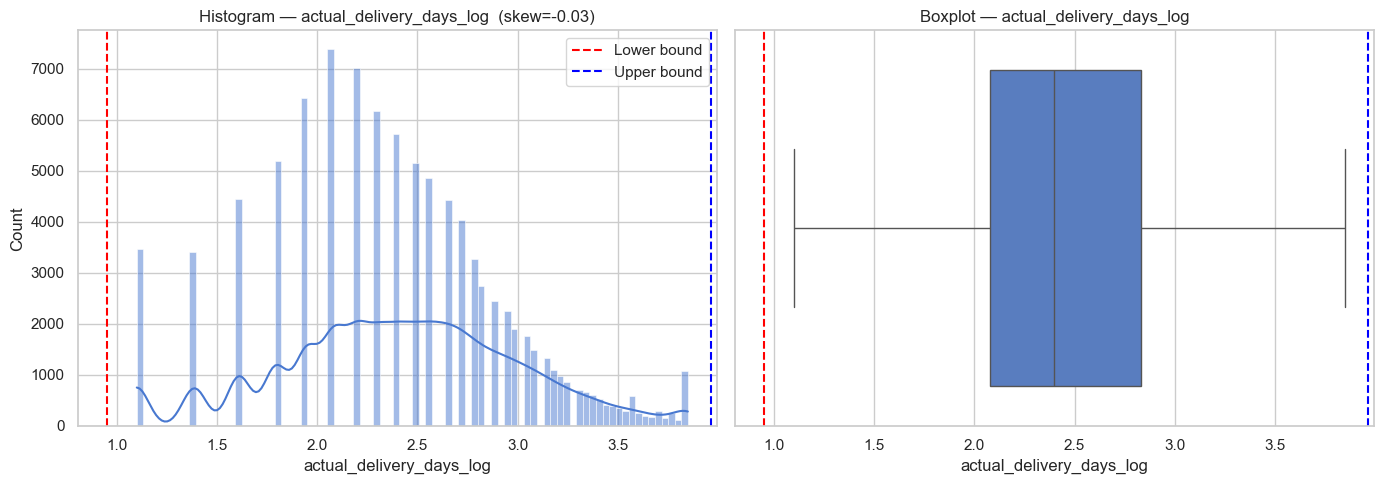

In [13]:
# Check distribution after processing
for col in ['delivery_delay_days', 'total_freight_value_log', 'freight_ratio_log', 
            'payment_value_log', 'carrier_to_customer_days', 'actual_delivery_days_log',
]:
    plot_hist_box(train_df, col)

# 3. Feature Encoding

## 3.1 Ordinal Encoding — Day of Week

In [14]:
# Check out categorical columns before encoding
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
train_df[cat_cols].head()

Categorical columns (5): ['payment_type', 'category_name_english', 'customer_state', 'seller_state', 'day_name']


,payment_type,category_name_english,customer_state,seller_state,day_name
0,boleto,housewares,MG,SP,Monday
1,boleto,garden_tools,SP,SP,Tuesday
2,boleto,sports_leisure,MG,PR,Tuesday
3,boleto,sports_leisure,SP,SP,Saturday
4,boleto,food,SP,SP,Monday


In [15]:
DAY_ORDER = {"Monday": 0, "Tuesday": 1, "Wednesday": 2,
             "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6}

train_df["day_name"] = train_df["day_name"].map(DAY_ORDER)

## 3.2 Label Encoding — State

In [16]:
# Label encoding 
for col in ['customer_state', 'seller_state']:
    le = LabelEncoder()
    train_df[f'{col}_enc'] = le.fit_transform(train_df[col])

train_df = train_df.drop(columns = ['customer_state', 'seller_state'])

## 3.3 One-Hot Encoding — Payment Type

In [17]:
# Onehot encoding
n_before = train_df.shape[1]
train_df = pd.get_dummies(train_df, columns=['payment_type'], drop_first=True, dtype = 'int')
new_cols = [c for c in train_df.columns if c.startswith("payment_type_")]
print(f"Total columns: {n_before} -> {train_df.shape[1]}")

Total columns: 27 -> 29


## 3.4 Target Encoding — Product Category

In [18]:
# Percentage
train_df['category_enc'] = np.nan
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

for train_idx, val_idx in kf.split(train_df, train_df['is_satisfied']):
    fold_map = (train_df.iloc[train_idx].groupby('category_name_english')['is_satisfied'].mean())
    train_df.loc[train_df.index[val_idx], "category_enc"] = (train_df.iloc[val_idx]["category_name_english"].map(fold_map))

train_df["category_enc"] = train_df["category_enc"].fillna(train_df["is_satisfied"].mean())
train_df = train_df.drop(columns=["category_name_english"])

In [19]:
train_df.head()

,is_satisfied,delivery_delay_days,estimated_delivery_days,actual_delivery_days,carrier_to_customer_days,review_answer_delay_days,total_order_value,total_items,payment_installments,customer_lat,...,total_freight_value_log,freight_ratio_log,payment_value_log,actual_delivery_days_log,customer_state_enc,seller_state_enc,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,category_enc
0,0,-15,22,7.0,5.0,1,34.59,1,1.0,-19.7402,...,2.616666,0.312545,3.572065,2.079442,10,21,0,0,0,0.198166
1,0,-8,21,13.0,6.0,3,126.54,2,1.0,-23.5324,...,3.322875,0.191694,4.848430,2.639057,25,21,0,0,0,0.202359
2,0,-6,14,8.0,7.0,0,127.55,1,1.0,-21.4106,...,3.355153,0.196224,4.856318,2.197225,10,14,0,0,0,0.181772
3,0,-13,20,7.0,4.0,0,112.71,1,1.0,-23.1948,...,2.688528,0.114756,4.733651,2.079442,25,21,0,0,0,0.183531
4,0,-7,9,2.0,1.0,0,35.84,1,1.0,-23.7409,...,2.190536,0.200080,3.606584,1.098612,25,21,0,0,0,0.155620


# 4. Feature Engineering

In [20]:
def haversine_formula(lat1, lon1, lat2, lon2):
    #Convert Radient
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

# Apply distance calculation to the entire dataframe
train_df['distance_km'] = haversine_formula(train_df['customer_lat'], train_df['customer_lng'], train_df['seller_lat'], train_df['seller_lng'])

# delivery_delay_days < 0 → giao sớm hơn dự kiến → signal mạnh
train_df['is_early_delivery'] = (train_df['delivery_delay_days'] < 0).astype(int)

# Clip + log transform khoảng cách (phân phối lệch phải)
lo, hi = train_df['distance_km'].quantile(0.01), train_df['distance_km'].quantile(0.99)
train_df['distance_km'] = train_df['distance_km'].clip(lo, hi)
train_df['distance_km_log'] = np.log1p(train_df['distance_km'])

train_df = train_df.drop(columns=['distance_km'])

In [21]:
# Percentage of actual and estimated delivery days
train_df['delivery_speed_ratio'] = (train_df['actual_delivery_days'] / train_df['estimated_delivery_days'].replace(0, np.nan)).clip(0.1, 5.0)  # clip outlier

# Best sellers = high review score AND low late rate
train_df['seller_reliability_score'] = (train_df['seller_avg_review_score'] * (1 - train_df['seller_late_rate']))
train_df = train_df.drop(columns=['seller_avg_review_score'])

# Order delayed from high-risk sellers = worst experience
train_df['delay_x_seller_risk'] = (train_df['delivery_delay_days'] * train_df['seller_late_rate'])

# 5. Export

In [22]:
print(f"Final shape: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"Missing values: {train_df.isnull().sum().sum()}")
print(f"Dtypes:\n{train_df.dtypes.value_counts().to_string()}")
train_df.head()

Final shape: 94,867 rows x 33 columns
Missing values: 0
Dtypes:
float64    19
int64      14


,is_satisfied,delivery_delay_days,estimated_delivery_days,actual_delivery_days,carrier_to_customer_days,review_answer_delay_days,total_order_value,total_items,payment_installments,customer_lat,...,seller_state_enc,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,category_enc,is_early_delivery,distance_km_log,delivery_speed_ratio,seller_reliability_score,delay_x_seller_risk
0,0,-15,22,7.0,5.0,1,34.59,1,1.0,-19.7402,...,21,0,0,0,0.198166,1,5.092836,0.318182,4.174000,-0.0000
1,0,-8,21,13.0,6.0,3,126.54,2,1.0,-23.5324,...,21,0,0,0,0.202359,1,5.986006,0.619048,3.691654,-0.6056
2,0,-6,14,8.0,7.0,0,127.55,1,1.0,-21.4106,...,14,0,0,0,0.181772,1,6.763933,0.571429,4.274262,-0.0594
3,0,-13,20,7.0,4.0,0,112.71,1,1.0,-23.1948,...,21,0,0,0,0.183531,1,5.522066,0.350000,3.816719,-1.0985
4,0,-7,9,2.0,1.0,0,35.84,1,1.0,-23.7409,...,21,0,0,0,0.155620,1,4.257464,0.222222,3.748683,-0.5558


In [23]:
# Save preprocessed dataset
out_path = base_dir / "data" / "processed" / "olist_preprocessed.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
train_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: c:\Users\Admin\Documents\Olist Data Analysis\data\processed\olist_preprocessed.csv
